In [1]:
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import scipy.stats as stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('tiitanic.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [5]:
df['Survived'].isnull().sum()

np.int64(0)

In [6]:
X=df.iloc[:,1:3]
Y=df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [8]:
X_train.columns

Index(['Age', 'Fare'], dtype='object')

In [9]:
X_test.shape

(179, 2)

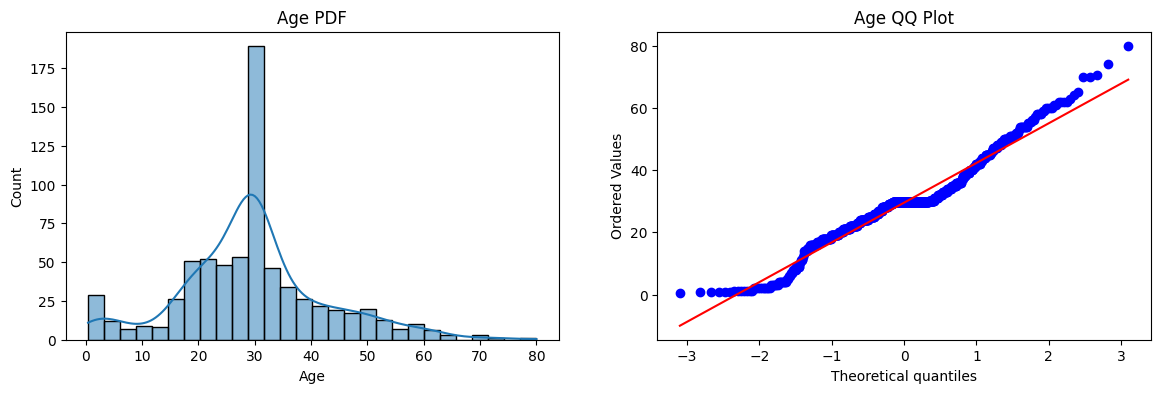

In [10]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

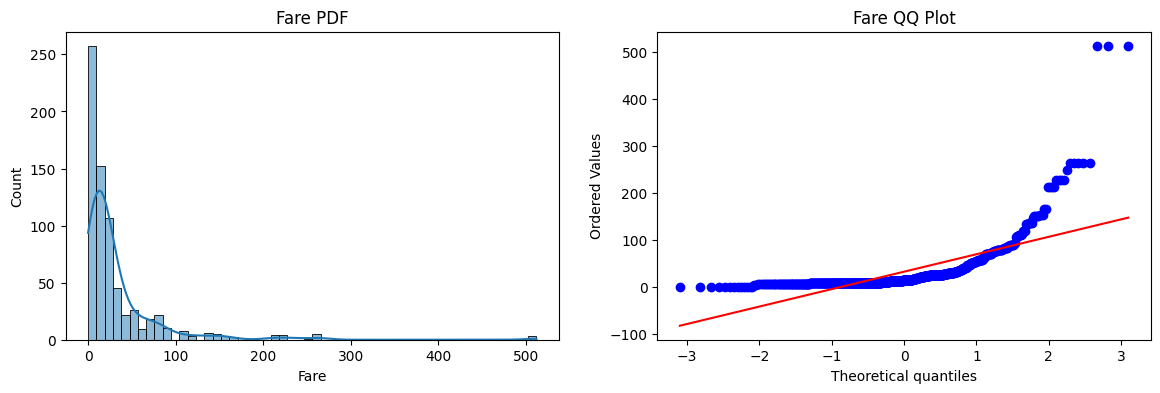

In [11]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [12]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

In [15]:
print("accuracy score LR",accuracy_score(y_test,y_pred))
print("accuracy score LR",accuracy_score(y_test,y_pred1))

accuracy score LR 0.6480446927374302
accuracy score LR 0.6703910614525139


In [16]:
trf=FunctionTransformer(func=np.log1p)

In [17]:
X_train_transformed=trf.fit_transform(X_train)
y_train_transformed=trf.transform(y_train)

In [18]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [19]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

In [21]:
print("accuracy score LR",accuracy_score(y_test,y_pred))
print("accuracy score LR",accuracy_score(y_test,y_pred1))

accuracy score LR 0.7374301675977654
accuracy score LR 0.5921787709497207


In [23]:
# 1. Fit on training data
X_train_transformed1 = trf_fare_only.fit_transform(X_train)

# 2. ONLY transform test data
X_test_transformed1 = trf_fare_only.transform(X_test)

# 3. Train models
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed1, y_train)
clf2.fit(X_train_transformed1, y_train)

# 4. Predict
y_pred = clf.predict(X_test_transformed1)
y_pred1 = clf2.predict(X_test_transformed1)

In [24]:
print("accuracy score LR",accuracy_score(y_test,y_pred))
print("accuracy score LR",accuracy_score(y_test,y_pred1))

accuracy score LR 0.6703910614525139
accuracy score LR 0.6815642458100558
